# 1. Imports

Aqui os imports usados para analise dos dados e pré processamento

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.basemap import Basemap
import geopandas as gpd
import geobr

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from datetime import datetime

# 2. Coleta de dados de fretes

Aqui vamos coletar os dados dos diversos CSV's para entender os precos de frete

In [11]:
order_items = pd.read_csv("./olist/olist_order_items_dataset.csv")

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [12]:
order = pd.read_csv("./olist/olist_orders_dataset.csv")

order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
products = pd.read_csv("./olist/olist_products_dataset.csv")

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [14]:
sellers = pd.read_csv("./olist/olist_sellers_dataset.csv")

sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [15]:
customers = pd.read_csv("./olist/olist_customers_dataset.csv")

customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [16]:
geo_data = pd.read_csv('./olist/olist_geolocation_dataset.csv')

geo_data_unique = geo_data.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

geo_data_unique.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,1001,-23.550190,-46.634024
1,1002,-23.548146,-46.634979
2,1003,-23.548994,-46.635731
3,1004,-23.549799,-46.634757
4,1005,-23.549456,-46.636733


C:\Users\Usuario\AppData\Local\Temp\ipykernel_14212\1414359806.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='geolocation_state', data=geo_data,


<Axes: xlabel='geolocation_state', ylabel='count'>

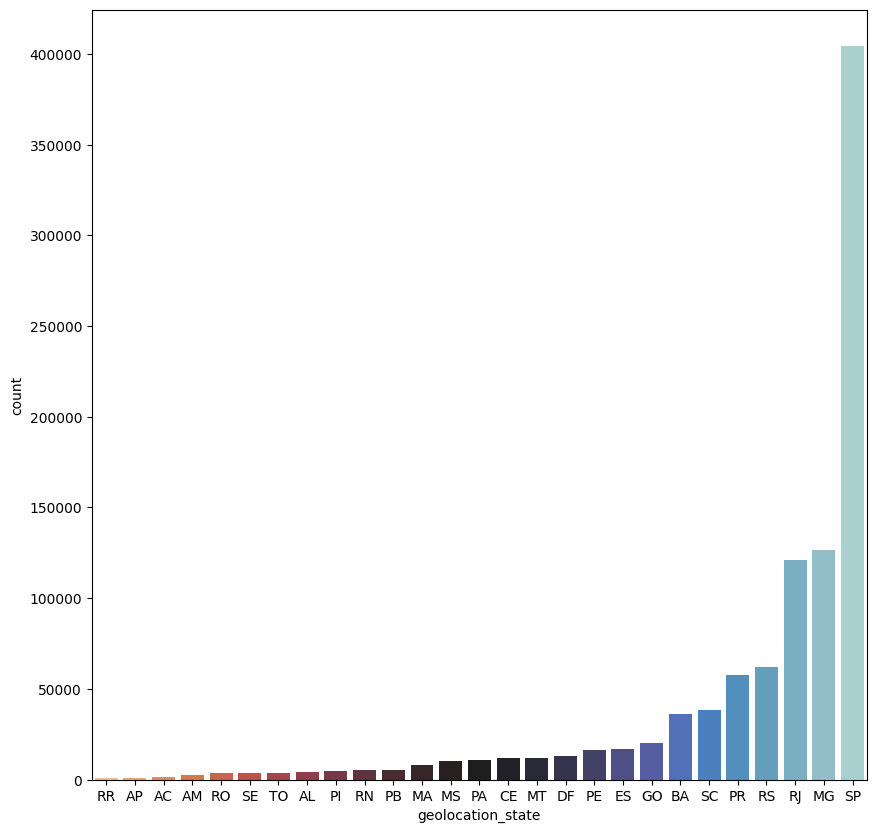

In [17]:
plt.figure(figsize=(10,10))
sns.countplot(x ='geolocation_state', data=geo_data, 
              order=geo_data['geolocation_state'].value_counts().sort_values().index, 
              palette='icefire_r')

In [18]:
def distanciaPontosLatLon(latitude_01, longitude_01, latitude_02, longitude_02):
    # 1. Converter graus para radianos
    lat1, lon1, lat2, lon2 = map(np.radians, [latitude_01, longitude_01, latitude_02, longitude_02])
    
    # 2. Diferenças
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # 3. Fórmula de Haversine
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    
    # 4. Cálculo final em KM
    r = 6371  # Raio médio da Terra em quilômetros
    distancia = 2 * r * np.arcsin(np.sqrt(a))
    
    return distancia
print(distanciaPontosLatLon(-22.496953, -44.127492, -21.762775, -41.309633))

301.5046663816336


**EDA**

In [19]:
# Qual a quantidade de fretes presentes no dataset


print(f"Numero de pedidos no dataset: {order_items.shape[0]}")

Numero de pedidos no dataset: 112650


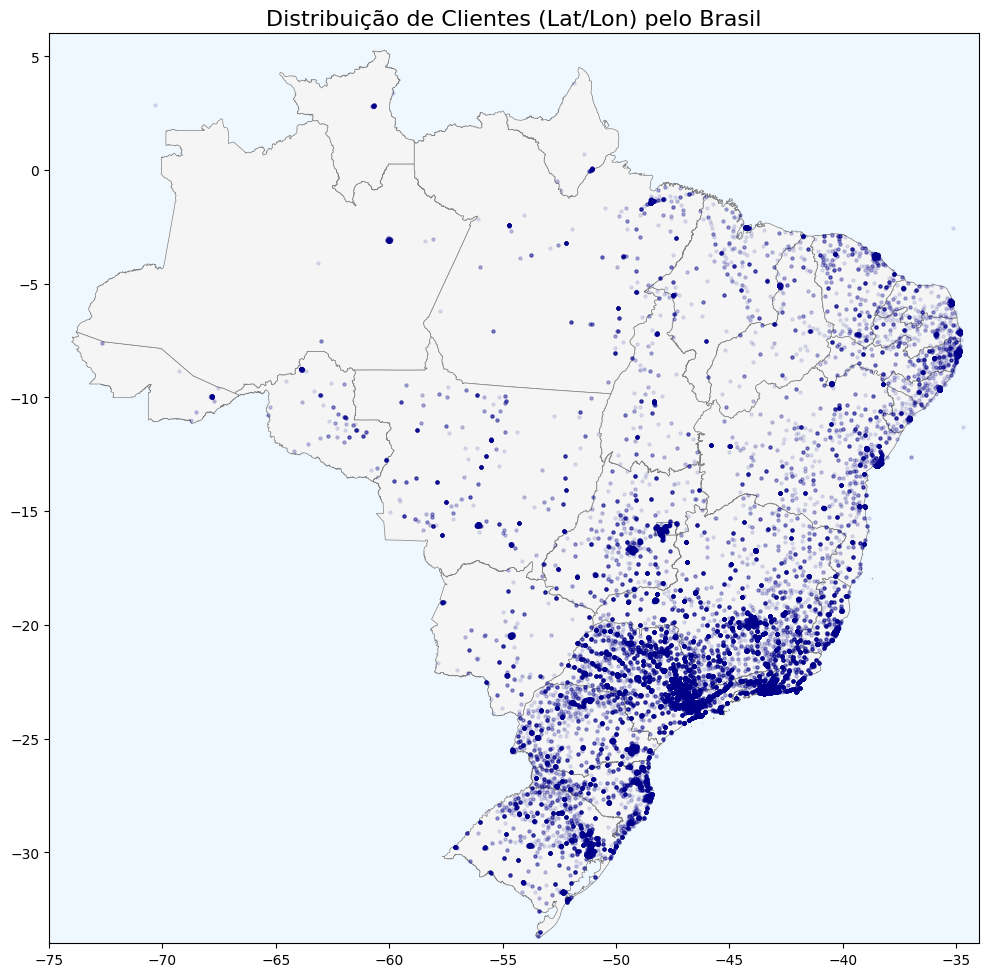

In [20]:
# Plot por latitude e longitude de cada consumidor

df_plot = pd.merge(order, customers, on='customer_id', how='left')
df_plot = pd.merge(df_plot, geo_data_unique, how="left", left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix' )

df_plot = df_plot.rename(
    columns={
        'geolocation_lat': 'customer_lat',
        'geolocation_lng': 'customer_lng'
    }).drop(columns=['geolocation_zip_code_prefix'])

brasil = geobr.read_state(year=2020)
df_mapa = df_plot.dropna(subset=['customer_lat', 'customer_lng'])

gdf_clientes = gpd.GeoDataFrame(
    df_mapa, 
    geometry=gpd.points_from_xy(df_mapa.customer_lng, df_mapa.customer_lat),
    crs="EPSG:4326" # Sistema de coordenadas GPS padrão
)

# Plotando tudo
fig, ax = plt.subplots(figsize=(12, 12))

# Pinta o fundo da imagem (Oceano/fundo geral)
ax.set_facecolor('aliceblue') 

# Pinta apenas o Brasil de 'whitesmoke' com bordas cinzas
brasil.plot(ax=ax, facecolor='whitesmoke', edgecolor='gray', linewidth=0.5)

# Plota os clientes por cima
gdf_clientes.plot(ax=ax, markersize=5, color='darkblue', alpha=0.1)

# Limita a visão para o tamanho do Brasil
ax.set_xlim([-75, -34])
ax.set_ylim([-34, 6])

plt.title('Distribuição de Clientes (Lat/Lon) pelo Brasil', fontsize=16)
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14212\576149718.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


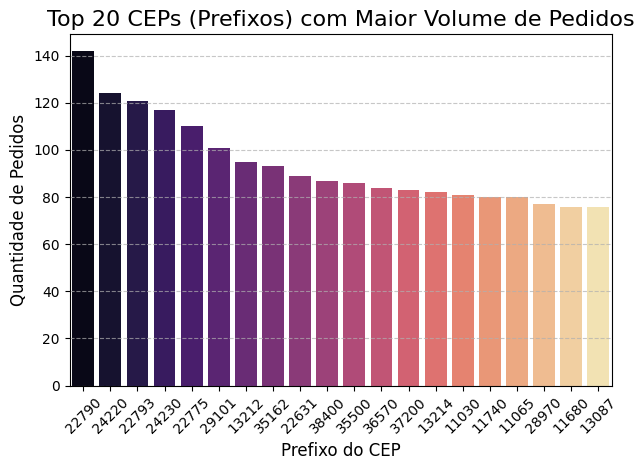

In [21]:
# plot por zip_code

top_ceps = df_plot['customer_zip_code_prefix'].value_counts().head(20)

# Plotando o gráfico de barras
sns.barplot(
    x=top_ceps.index.astype(str), # Transforma em string para o eixo X ficar como categoria
    y=top_ceps.values, 
    palette='magma'
)

plt.title('Top 20 CEPs (Prefixos) com Maior Volume de Pedidos', fontsize=16)
plt.xlabel('Prefixo do CEP', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
plt.xticks(rotation=45) # Rotaciona os números do CEP para não sobrepor
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14212\1172059778.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


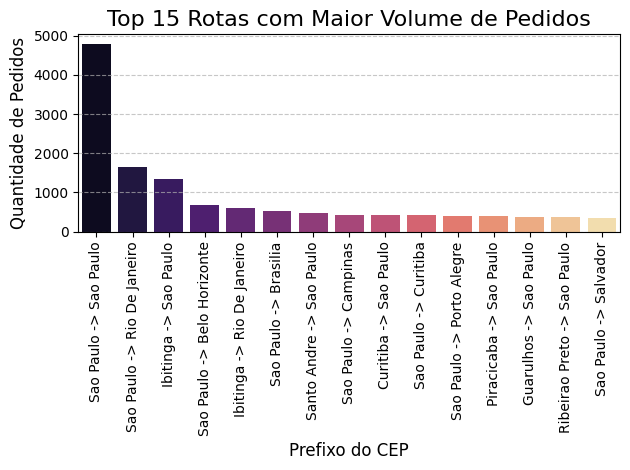

In [22]:

df_plot = pd.merge(order_items, products, on='product_id', how='left')
df_plot = pd.merge(df_plot, order, on='order_id', how='left')
df_plot = pd.merge(df_plot, customers, on='customer_id', how='left')

df_plot = pd.merge(df_plot, geo_data_unique, how="left", left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix')
df_plot = df_plot.rename(
    columns={
        'geolocation_lat': 'customer_lat',
        'geolocation_lng': 'customer_lng'
    }).drop(columns=['geolocation_zip_code_prefix'])

df_plot = pd.merge(df_plot, sellers, on='seller_id', how='left')

df_plot = pd.merge(df_plot, geo_data_unique, how="left", left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix')
df_plot = df_plot.rename(
    columns={
        'geolocation_lat': 'seller_lat',
        'geolocation_lng': 'seller_lng'
    }).drop(columns=['geolocation_zip_code_prefix'])

df_plot['rota_cidade'] = df_plot['seller_city'].str.title() + " -> " + df_plot['customer_city'].str.title()
rotas_mais_comuns = df_plot['rota_cidade'].value_counts().head(15)

# Plotando o gráfico de barras
sns.barplot(
    x=rotas_mais_comuns.index.astype(str), # Transforma em string para o eixo X ficar como categoria
    y=rotas_mais_comuns.values, 
    palette='magma'
)

plt.title('Top 15 Rotas com Maior Volume de Pedidos', fontsize=16)
plt.xlabel('Prefixo do CEP', fontsize=12)
plt.ylabel('Quantidade de Pedidos', fontsize=12)
plt.xticks(rotation=90) # Rotaciona os números do CEP para não sobrepor
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Numero de grupos existentes 73
Categoria: cama_mesa_banho --> 3029 itens
Categoria: esporte_lazer --> 2867 itens
Categoria: moveis_decoracao --> 2657 itens
Categoria: beleza_saude --> 2444 itens
Categoria: utilidades_domesticas --> 2335 itens
Categoria: automotivo --> 1900 itens
Categoria: informatica_acessorios --> 1639 itens
Categoria: brinquedos --> 1411 itens
Categoria: relogios_presentes --> 1329 itens
Categoria: telefonia --> 1134 itens
Categoria: bebes --> 919 itens
Categoria: perfumaria --> 868 itens
Categoria: papelaria --> 849 itens
Categoria: fashion_bolsas_e_acessorios --> 849 itens
Categoria: cool_stuff --> 789 itens
Categoria: ferramentas_jardim --> 753 itens
Categoria: pet_shop --> 719 itens
Categoria: eletronicos --> 517 itens
Categoria: construcao_ferramentas_construcao --> 400 itens
Categoria: eletrodomesticos --> 370 itens
Categoria: malas_acessorios --> 349 itens
Categoria: consoles_games --> 317 itens
Categoria: moveis_escritorio --> 309 itens
Categoria: instrument

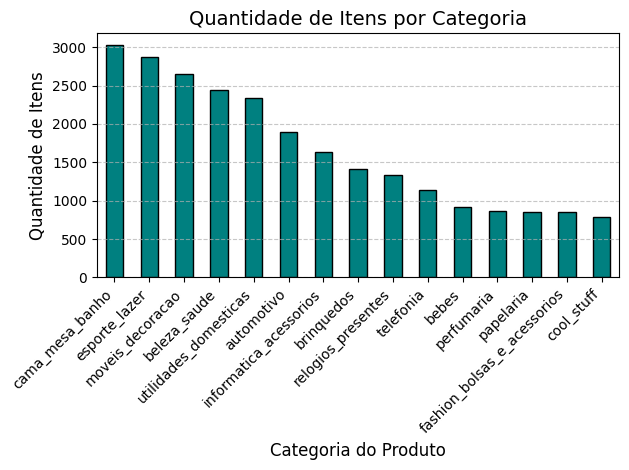

In [23]:
# Quais categorias de produtos existem

categorias = products.groupby('product_category_name')
print(f"Numero de grupos existentes {categorias.ngroups}")

categorias = categorias.size().sort_values(ascending=False)

for cat, quant in categorias.items():
    print(f"Categoria: {cat} --> {quant} itens")

categorias.head(15).plot(kind='bar', color='teal', edgecolor='black')

plt.title('Quantidade de Itens por Categoria', fontsize=14)
plt.ylabel('Quantidade de Itens', fontsize=12)
plt.xlabel('Categoria do Produto', fontsize=12)

# Rotacionar os nomes no eixo X para caber direitinho
plt.xticks(rotation=45, ha='right') 

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

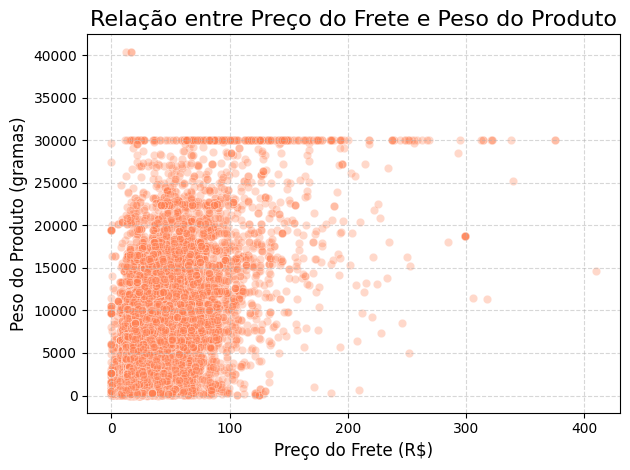

In [24]:
# gráfico x: preço do frete, y: weight produto

df_plot = pd.merge(order_items, products, on='product_id', how='left')
df_plot = df_plot.dropna()

sns.scatterplot(
    data=df_plot,
    x='freight_value', 
    y='product_weight_g',
    alpha=0.3,
    color='coral'
)

# Ajustando Títulos e Eixos
plt.title('Relação entre Preço do Frete e Peso do Produto', fontsize=16)
plt.xlabel('Preço do Frete (R$)', fontsize=12)
plt.ylabel('Peso do Produto (gramas)', fontsize=12)

# Adicionando um grid de fundo para facilitar a leitura dos valores
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

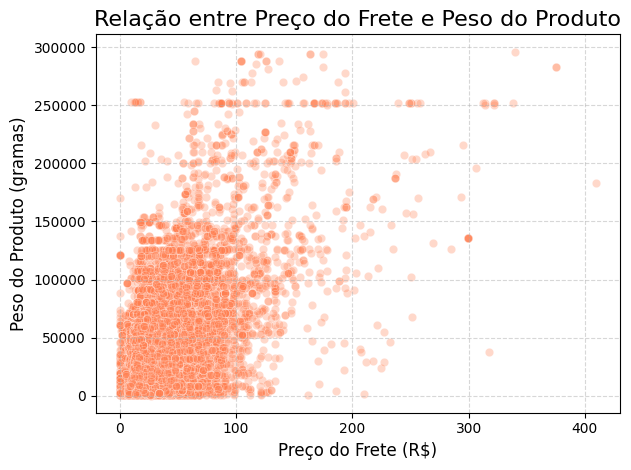

In [25]:
# gráfico x: preço do frete, y: volume (base,altura,profundidade) produto

df_plot = pd.merge(order_items, products, on='product_id', how='left')
df_plot['volume'] =  df_plot['product_length_cm'] * df_plot['product_height_cm'] *  df_plot['product_width_cm']

df_plot = df_plot.dropna()

sns.scatterplot(
    data=df_plot, 
    x='freight_value', 
    y='volume',
    alpha=0.3,
    color='coral'
)

# Ajustando Títulos e Eixos
plt.title('Relação entre Preço do Frete e Peso do Produto', fontsize=16)
plt.xlabel('Preço do Frete (R$)', fontsize=12)
plt.ylabel('Peso do Produto (gramas)', fontsize=12)

# Adicionando um grid de fundo para facilitar a leitura dos valores
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Organizando as tabelas contendo os dados que eu preciso para prever o frete com base no dataset

In [26]:
# 2. Fazer os cruzamentos (Merges)
# Juntar itens com dados do produto (para pegar peso e dimensões)
df_frete = pd.merge(order_items, products, on='product_id', how='left')

# Juntar com os dados do vendedor (origem)
df_frete = pd.merge(df_frete, sellers, on='seller_id', how='left')

# Juntar com os pedidos (para pegar o ID do cliente e datas)
df_frete = pd.merge(df_frete, order, on='order_id', how='left')

# Juntar com os dados do cliente (destino)
df_frete = pd.merge(df_frete, customers, on='customer_id', how='left')

# Juntar os dados dos vendedores com a sua localizacao no espaco para calculo de distancia dps
df_frete = pd.merge(df_frete, geo_data_unique, how="left", left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix')
df_frete = df_frete.rename(
    columns={
        'geolocation_lat': 'seller_lat',
        'geolocation_lng': 'seller_lng'
    }).drop(columns=['geolocation_zip_code_prefix'])

df_frete = pd.merge(df_frete, geo_data_unique, how="left", left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix')
df_frete = df_frete.rename(
    columns={
        'geolocation_lat': 'customer_lat',
        'geolocation_lng': 'customer_lng'
    }).drop(columns=['geolocation_zip_code_prefix'])

df_frete.head()

print(df_frete[['seller_zip_code_prefix', 'seller_lat', 'seller_lng', 'customer_zip_code_prefix','customer_lat', 'customer_lng']].head())

   seller_zip_code_prefix  seller_lat  seller_lng  customer_zip_code_prefix  \
0                   27277  -22.496953  -44.127492                     28013   
1                    3471  -23.565096  -46.518565                     15775   
2                   37564  -22.262584  -46.171124                     35661   
3                   14403  -20.553624  -47.387359                     12952   
4                   87900  -22.929384  -53.135873                     13226   

   customer_lat  customer_lng  
0    -21.762775    -41.309633  
1    -20.220527    -50.903424  
2    -19.870305    -44.593326  
3    -23.089925    -46.611654  
4    -23.243402    -46.827614  


In [27]:
# Aqui vamos configurar a distancia entre cada um dos pedidos e fazer mais alteracoes como dexar o minimo de nulos possivei e configurar dias
df_frete['distancia_km'] = distanciaPontosLatLon(
    df_frete['seller_lat'], 
    df_frete['seller_lng'], 
    df_frete['customer_lat'], 
    df_frete['customer_lng']
)

# Converter data para datetime e extrair features temporais
df_frete['order_purchase_timestamp'] = pd.to_datetime(df_frete['order_purchase_timestamp'])
df_frete['mes'] = df_frete['order_purchase_timestamp'].dt.month
df_frete['dia_semana'] = df_frete['order_purchase_timestamp'].dt.weekday
df_frete['ano'] = df_frete['order_purchase_timestamp'].dt.year  

# Transformar colunas de texto (Categorias e Estados) em códigos numéricos (Label Encoding)
for col in ['product_category_name', 'seller_state', 'customer_state']:
    df_frete[col] = df_frete[col].astype('category').cat.codes

# Remover linhas com valores nulos que impediriam o treino
df_final = df_frete.dropna(subset=['distancia_km', 'freight_value', 'product_weight_g'])

df_final = df_final.sort_values('order_purchase_timestamp')




**Matriz de correlação de features**

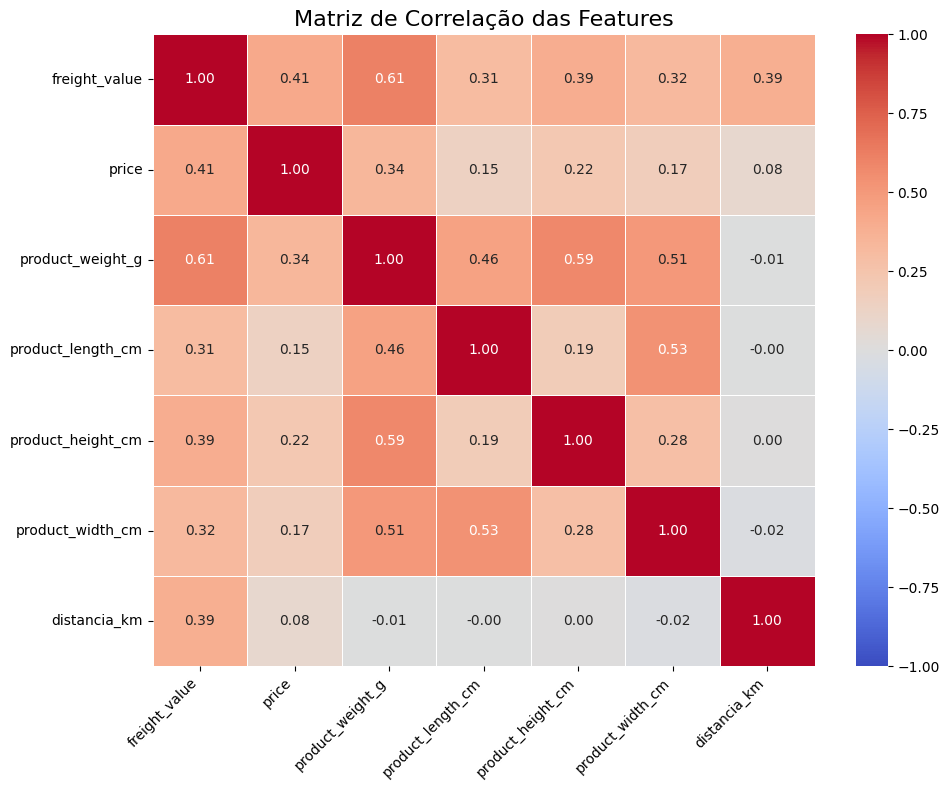

In [28]:
# 1. Selecionamos as colunas numéricas que queremos entender
colunas_para_correlacao = [
    'freight_value', 
    'price', 
    'product_weight_g', 
    'product_length_cm', 
    'product_height_cm', 
    'product_width_cm',
    'distancia_km'
]

# 2. Criamos um DataFrame apenas com essas colunas usando sua base final
df_corr = df_final[colunas_para_correlacao]

# 3. Calculamos a matriz de correlação (Pearson)
matriz_corr = df_corr.corr()

# 4. Plotamos o gráfico (Heatmap)
plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_corr, 
    annot=True,          # Mostra o valor numérico dentro do quadrado
    cmap='coolwarm',     # Cores: Vermelho (forte positiva) / Azul (forte negativa)
    fmt=".2f",           # Arredonda para 2 casas decimais
    linewidths=0.5,      # Bordas brancas nos quadrados
    vmin=-1, vmax=1      # Escala sempre de -1 a 1
)

plt.title('Matriz de Correlação das Features', fontsize=16)
plt.xticks(rotation=45, ha='right') # Arruma o texto do eixo X

plt.tight_layout()
plt.show()

# 3. Random Forest

Nesse capitulo vamos utilizar a tecnica de random floret para previsao do frete principalmente ver sobre a sua implemnetacao com base no banco de dados que criamos ba parte 2

In [29]:
class RandomForestRegressorOlist(RandomForestRegressor):
    def __init__(self, X_train, y_train, X_val, y_val, n_estimators=100, max_depth=15, random_state=42, n_jobs=-1, min_samples_split = 2, max_features = 1.0):
        '''
        X: Colunas preditivas
        y: colunas alvo
        
        '''
        super().__init__(
            n_estimators=n_estimators, 
            max_depth=max_depth, 
            random_state=random_state, 
            n_jobs=n_jobs,
            min_samples_split=min_samples_split,
            max_features = max_features
        )

        self.X_train, self.y_train = X_train, y_train
        self.X_val, self.y_val = X_val, y_val
        self.feature_names = X_train.columns.tolist()

        print(f"Dados de Treino: {self.X_train.shape[0]} amostras")
        print(f"Dados de Validação: {self.X_val.shape[0]} amostras")
    
    def train(self):
        self.fit(self.X_train, self.y_train)

    def evaluate(self, X_target=None, y_target=None, label="Validação"):
        """Avalia o modelo. Pode ser usado para Validação ou Teste Final."""
        # Se não passarmos dados novos, ele usa os de validação padrão
        X_eval = X_target if X_target is not None else self.X_val
        y_eval = y_target if y_target is not None else self.y_val
        
        y_pred = self.predict(X_eval)
        mae = mean_absolute_error(y_eval, y_pred)
        r2 = r2_score(y_eval, y_pred)
        rmse = np.sqrt(mean_squared_error(self.y_val, y_pred))
        
        print("\n📊 --- Performance do Modelo ---")
        print(f"Erro Médio Absoluto (MAE): R$ {mae:.2f}")
        print(f"Raiz do Erro Quadrático (RMSE): R$ {rmse:.2f}")
        print(f"Coeficiente de Determinação (R²): {r2:.4f}")
    
    def show_feature_importance(self, top_n=15):
        """Exibe quais colunas mais influenciaram o preço do frete."""
        importancias = pd.Series(
            self.feature_importances_, 
            index=self.feature_names
        ).sort_values(ascending=False)
        
        print(f"\n💡 Top {top_n} Atributos mais Importantes:")
        print(importancias.head(top_n))
        return importancias

In [33]:
# 1. Definir os pontos de corte (proporção 70/15/15)
total_linhas = len(df_final)
treino_fim = int(total_linhas * 0.7)
validacao_fim = int(total_linhas * 0.85)

# 2. Criar os três conjuntos
df_treino = df_final.iloc[:treino_fim]
df_validacao = df_final.iloc[treino_fim:validacao_fim]
df_teste = df_final.iloc[validacao_fim:]

print(f"Treino: {len(df_treino)} linhas (De {df_treino['order_purchase_timestamp'].min()} Até {df_treino['order_purchase_timestamp'].max()})")
print(f"Validação: {len(df_validacao)} linhas (De {df_validacao['order_purchase_timestamp'].min()} Até {df_validacao['order_purchase_timestamp'].max()})")
print(f"Teste Final: {len(df_teste)} linhas (De {df_teste['order_purchase_timestamp'].min()} Até {df_teste['order_purchase_timestamp'].max()})")

features = [
    'price', 'product_category_name', 'product_weight_g', 
    'product_length_cm', 'product_height_cm', 'product_width_cm',
    'seller_state', 'customer_state', 'mes', 'dia_semana',
    'seller_lat', 'seller_lng', 'customer_lat', 'customer_lng', 'distancia_km'
]
features = [ 
    'price', 
    'product_weight_g', 
    'product_length_cm', 
    'product_height_cm', 
    'product_width_cm',
    'distancia_km',
    'mes', 'dia_semana',
]


# Matrizes de Treino
X_train = df_treino[features]
y_train = df_treino['freight_value']

# Matrizes de Validação (Para ajuste fino)
X_val = df_validacao[features]
y_val = df_validacao['freight_value']

# Matrizes de Teste (O "Veredito Final")
X_test = df_teste[features]
y_test = df_teste['freight_value']

RegressorOlist = RandomForestRegressorOlist(
    X_train, y_train, 
    X_val, y_val, 
    n_estimators=200, 
    max_depth=20,
    min_samples_split=5,
    max_features="log2"
)

Treino: 78454 linhas (De 2016-09-04 21:15:19 Até 2018-04-14 19:05:41)
Validação: 16812 linhas (De 2018-04-14 19:16:01 Até 2018-06-20 00:46:19)
Teste Final: 16812 linhas (De 2018-06-20 02:49:42 Até 2018-09-03 09:06:57)
Dados de Treino: 78454 amostras
Dados de Validação: 16812 amostras


In [34]:
# TESTEEEEE, vamos ver como o modelo se comporta
RegressorOlist.train()

In [35]:

RegressorOlist.evaluate()
RegressorOlist.evaluate(X_test, y_test, label="Teste Final (Dados Inéditos)")
RegressorOlist.show_feature_importance()



📊 --- Performance do Modelo ---
Erro Médio Absoluto (MAE): R$ 5.49
Raiz do Erro Quadrático (RMSE): R$ 11.24
Coeficiente de Determinação (R²): 0.5898

📊 --- Performance do Modelo ---
Erro Médio Absoluto (MAE): R$ 5.50
Raiz do Erro Quadrático (RMSE): R$ 20.66
Coeficiente de Determinação (R²): 0.5849

💡 Top 15 Atributos mais Importantes:
product_weight_g     0.321878
distancia_km         0.241971
price                0.150895
product_height_cm    0.113428
product_width_cm     0.067543
product_length_cm    0.064838
mes                  0.022944
dia_semana           0.016503
dtype: float64


product_weight_g     0.321878
distancia_km         0.241971
price                0.150895
product_height_cm    0.113428
product_width_cm     0.067543
product_length_cm    0.064838
mes                  0.022944
dia_semana           0.016503
dtype: float64